In [1]:
# ============================================================
# Imports & Configuration
# ============================================================

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from config import SHEPP_LOGAN_PATH, IMAGE_SIZE, N_MEASUREMENTS, RANDOM_SEED
from src.operators import MeasurementOperator

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

# 1. Load and inspect the raw image

In [3]:
X_true = np.load(SHEPP_LOGAN_PATH)

print(f"Shape: {X_true.shape}")
print(f"dtype: {X_true.dtype}")
print(f"Value range: [{X_true.min():.4f}, {X_true.max():.4f}]")
print(f"Rank (full SVD, tol=1e-3): ", end="")

sigma = np.linalg.svd(X_true, compute_uv=False)
print(np.sum(sigma > 1e-2))

Shape: (128, 128)
dtype: float64
Value range: [0.0000, 1.0000]
Rank (full SVD, tol=1e-3): 71


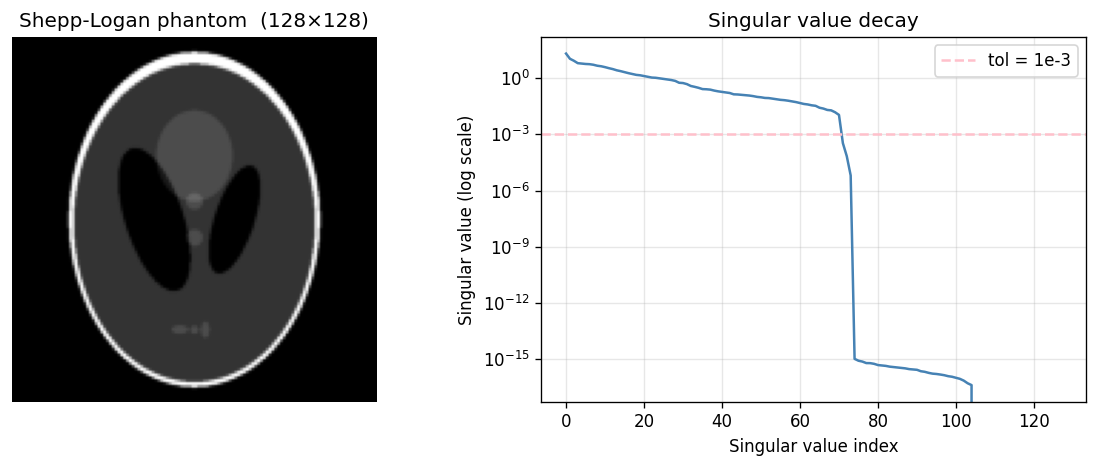

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(X_true)
axes[0].set_title(f"Shepp-Logan phantom  ({X_true.shape[0]}×{X_true.shape[1]})")
axes[0].axis('off')

axes[1].semilogy(sigma, color='steelblue', linewidth=1.5)
axes[1].set_xlabel("Singular value index")
axes[1].set_ylabel("Singular value (log scale)")
axes[1].set_title("Singular value decay")
axes[1].axhline(y=1e-3, color='pink', linestyle='--', label='tol = 1e-3')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

The singular value plot should drop steeply, then a long tail near zero. That steep decay is why the low-rank prior works for this image. If the decay were flat, matrix completion would fail.

# 2. Inspect the measurement matrix A

In [4]:
op = MeasurementOperator(n=IMAGE_SIZE, m=N_MEASUREMENTS, seed=RANDOM_SEED)

print(f"A shape: {op.A.shape} | (m x (nxn)  =  {N_MEASUREMENTS} × {IMAGE_SIZE**2})")
print(f"A mean: {op.A.mean():.6f} (should be ~ 0)")
print(f"A std: {op.A.std():.6f} (should be ≈ 1/sqrt(m) = {1/np.sqrt(N_MEASUREMENTS):.6f})")


A shape: (700, 16384) | (m x (nxn)  =  700 × 16384)
A mean: 0.000002 (should be ~ 0)
A std: 0.037788 (should be ≈ 1/sqrt(m) = 0.037796)


In [5]:
# Check RIP: A^T A should be ~ I  (check a small submatrix for speed)
sub = op.A[:, :200]
ATA_sub = sub.T @ sub
off_diag = ATA_sub - np.diag(np.diag(ATA_sub))

print(f"\nRIP check on 200-col submatrix:")
print(f"  diagonal mean: {np.diag(ATA_sub).mean():.4f}  (should be ~ 1.0)")
print(f"  off-diagonal std: {off_diag.std():.4f}  (should be small)")


RIP check on 200-col submatrix:
  diagonal mean: 1.0098  (should be ~ 1.0)
  off-diagonal std: 0.0379  (should be small)


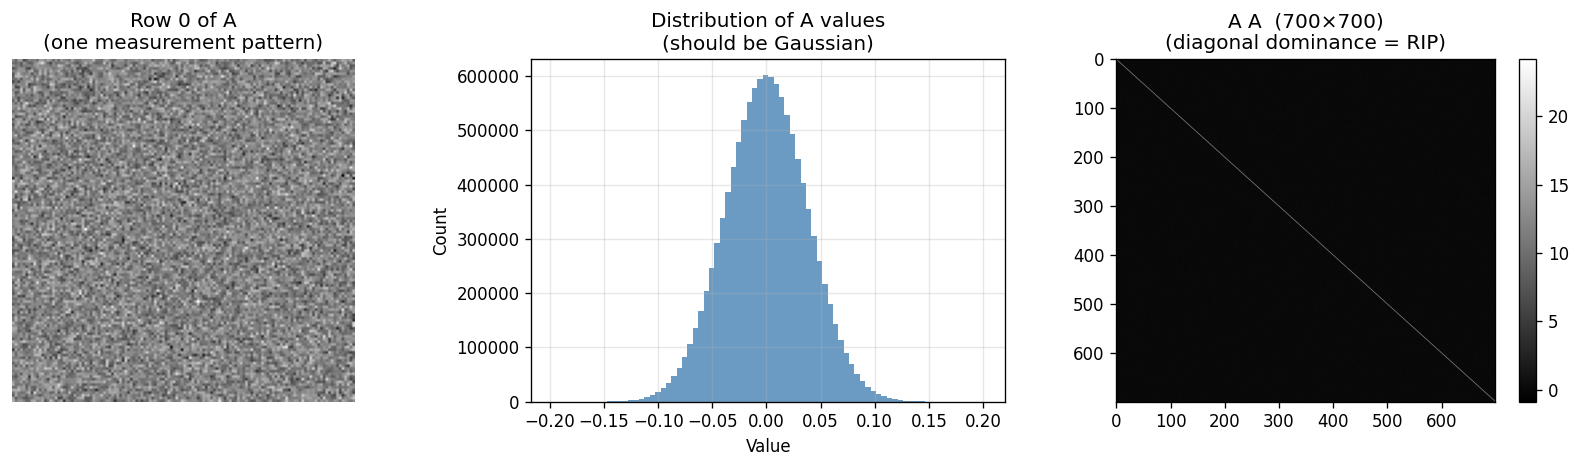

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Row 0 of A reshaped as an image — one measurement pattern
axes[0].imshow(op.A[0].reshape(IMAGE_SIZE, IMAGE_SIZE))
axes[0].set_title("Row 0 of A\n(one measurement pattern)")
axes[0].axis('off')

# Distribution of A values
axes[1].hist(op.A.ravel(), bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_title("Distribution of A values\n(should be Gaussian)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

# Gram matrix A A^T visualised — should look like scaled identity
AAT = op.A @ op.A.T
im = axes[2].imshow(AAT, aspect='auto')
axes[2].set_title(f"A A  ({op.m}×{op.m})\n(diagonal dominance = RIP)")
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()


Matrix A should looks like random static, each measurement sees every pixel with a random weight. The A A^T matrix should be strongly diagonal-dominant, confirming the RIP scaling is working.

# 3. Generate and inspect measurements y = A(X)

In [7]:
y = op.measure(X_true)

print(f"y shape: {y.shape}")
print(f"y range: [{y.min():.4f}, {y.max():.4f}]")
print(f"y mean: {y.mean():.4f}")
print(f"y std: {y.std():.4f}")
print(f"\nSampling ratio: m/(nxn) = {N_MEASUREMENTS}/{IMAGE_SIZE**2} = {N_MEASUREMENTS/IMAGE_SIZE**2:.4f}")
print(f"Observed {100*N_MEASUREMENTS/IMAGE_SIZE**2:.1f}% of possible measurements")


y shape: (700,)
y range: [-3.3515, 4.7442]
y mean: -0.0632
y std: 1.1183

Sampling ratio: m/(nxn) = 700/16384 = 0.0427
Observed 4.3% of possible measurements


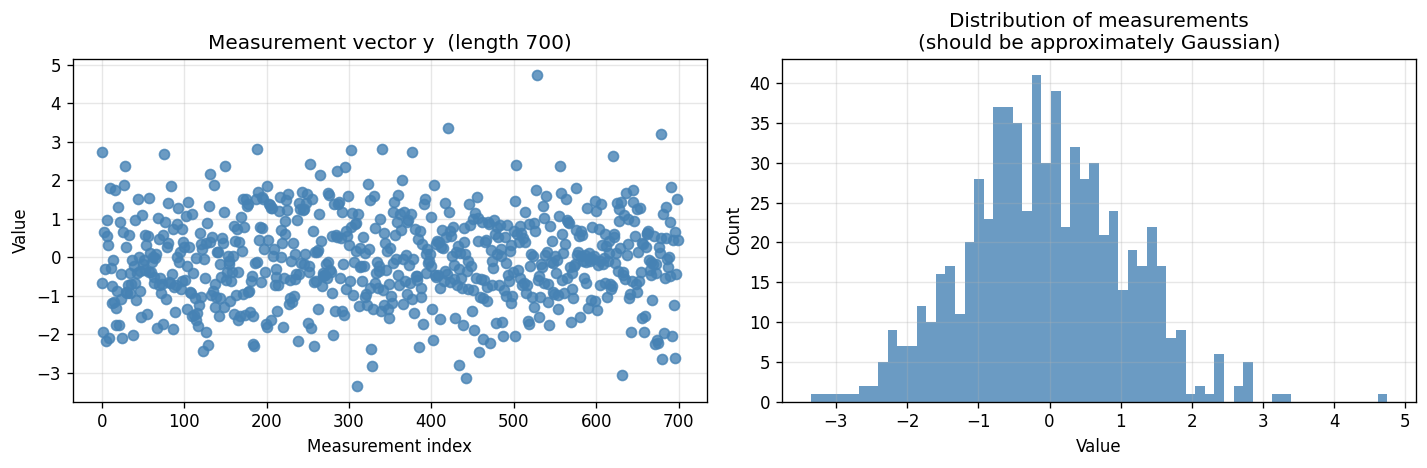

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(y,color='steelblue', linewidth=0, alpha=0.8, marker='o')
axes[0].set_title(f"Measurement vector y  (length {len(y)})")
axes[0].set_xlabel("Measurement index")
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)

axes[1].hist(y, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_title("Distribution of measurements\n(should be approximately Gaussian)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

y is just a vector of 700 numbers. It contains all the information the solver has. One can't reconstruct the image by just looking at y as it is compressed.

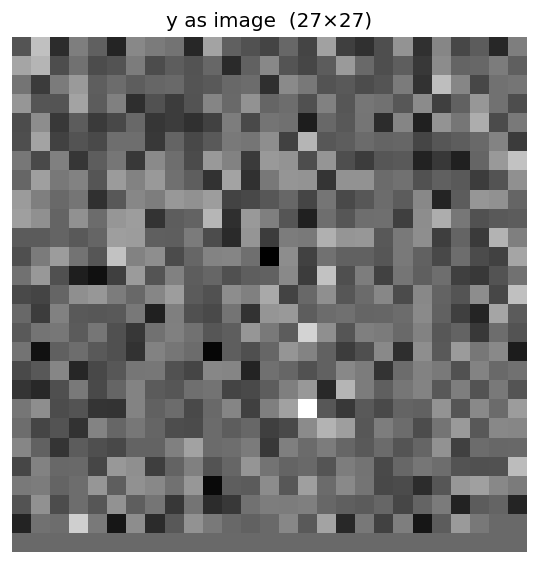

In [9]:
fig, axes = plt.subplots(1)

# Reshape y into nearest square for visualisation
# 700 → pad to 27×26 = 702
side = int(np.ceil(np.sqrt(len(y))))
y_padded = np.pad(y, (0, side*side - len(y)), constant_values=0)
y_image = y_padded.reshape(side, side)

axes.imshow(y_image)
axes.set_title(f"y as image  ({side}×{side})")
axes.axis('off')

'''axes[1].hist(y, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_title("Distribution of y\n(approximately Gaussian)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)'''

plt.tight_layout()
plt.show()

# 4. Backprojection A*(y)

What the solver starts from

In [10]:
backprojection = op.adjoint(y)

print(f"Backprojection shape: {backprojection.shape}")
print(f"Value range: [{backprojection.min():.4f}, {backprojection.max():.4f}]")

# Relative error of backprojection vs true image
rel_err = np.linalg.norm(backprojection - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
print(f"Relative error vs X_true : {rel_err:.4f}  (high is expected — this is pre-solver)")


Backprojection shape: (128, 128)
Value range: [-4.4339, 4.4788]
Relative error vs X_true : 4.7627  (high is expected — this is pre-solver)


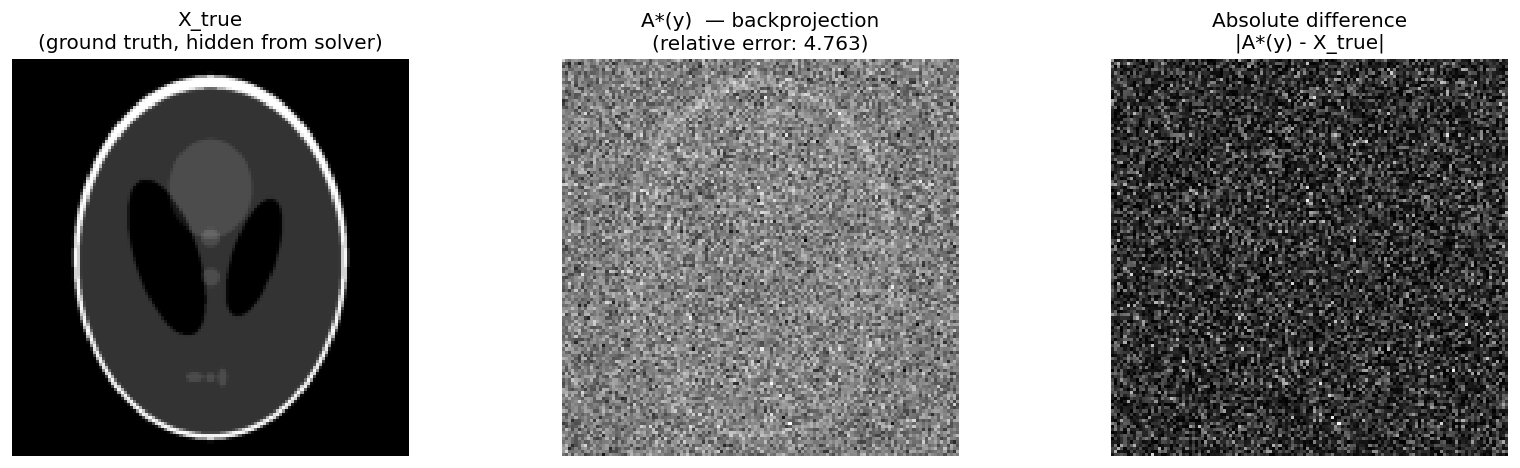

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(X_true)
axes[0].set_title("X_true\n(ground truth, hidden from solver)")
axes[0].axis('off')


axes[1].imshow(backprojection)
axes[1].set_title(f"A*(y)  — backprojection\n(relative error: {rel_err:.3f})")
axes[1].axis('off')

diff = np.abs(backprojection - X_true)
axes[2].imshow(diff)
axes[2].set_title("Absolute difference\n|A*(y) - X_true|")
axes[2].axis('off')

plt.tight_layout()
plt.show()

The backprojection should look like a blurry copy of the original image. Note that it's not random noise because A*(y) already contains structural information, however, it is smeared across the whole image. The ADMM solver takes this smeared starting point and find the lowest-rank matrix that exactly fits the measurements.

# 5. Adjoint test 

In [12]:
rng = np.random.default_rng(0)

errors = []
for _ in range(200):
    X_rand = rng.standard_normal((IMAGE_SIZE, IMAGE_SIZE))
    u_rand = rng.standard_normal(N_MEASUREMENTS)
    
    lhs = np.dot(op.forward(X_rand), u_rand)
    rhs = np.dot(X_rand.ravel(), op.adjoint(u_rand).ravel())
    errors.append(abs(lhs - rhs))

errors = np.array(errors)

print(f"Adjoint test over 200 random pairs:")
print(f"  max  |<A(X),u> - <X,A*(u)>| = {errors.max():.2e}")
print(f"  mean |<A(X),u> - <X,A*(u)>| = {errors.mean():.2e}")
print(f"  all below 1e-8? {np.all(errors < 1e-8)}")

Adjoint test over 200 random pairs:
  max  |<A(X),u> - <X,A*(u)>| = 3.13e-13
  mean |<A(X),u> - <X,A*(u)>| = 9.29e-14
  all below 1e-8? True


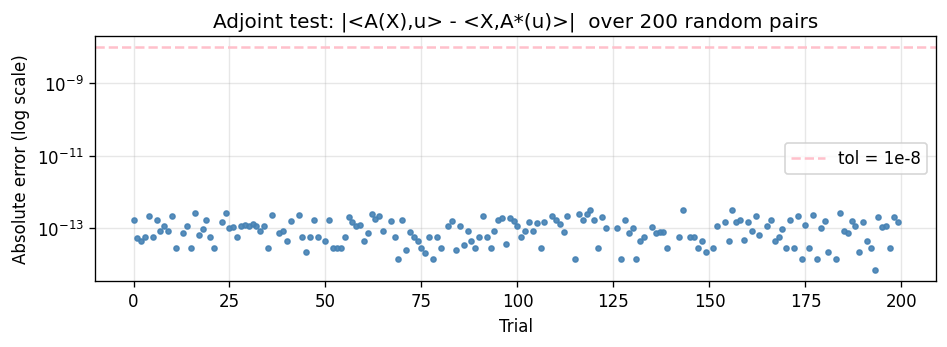

In [17]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(errors, color='steelblue', linewidth=0, alpha=0.9, marker=".")
ax.axhline(y=1e-8, color='pink', linestyle='--', label='tol = 1e-8')
ax.set_title("Adjoint test: |<A(X),u> - <X,A*(u)>|  over 200 random pairs")
ax.set_xlabel("Trial")
ax.set_ylabel("Absolute error (log scale)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [14]:
assert np.all(errors < 1e-8), "Adjoint test failed — fix operators.py before proceeding"
print("\nAdjoint test passed. Safe to proceed to admm.py.")


Adjoint test passed. Safe to proceed to admm.py.
